# Dostrajanie SAMa 🎻

## Pobieranie wag oraz danych

In [1]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

In [2]:
!wget https://datasets.simula.no/downloads/kvasir-seg.zip --no-check-certificate
!unzip -q kvasir-seg.zip

--2026-05-30 12:13:40--  https://datasets.simula.no/downloads/kvasir-seg.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 46227172 (44M) [application/zip]
Saving to: ‘kvasir-seg.zip’

kvasir-seg.zip      100%[===================>]  44.08M  36.0MB/s    in 1.2s    

2026-05-30 12:13:41 (36.0 MB/s) - ‘kvasir-seg.zip’ saved [46227172/46227172]



## Instalacja SAMa i Gradio

In [3]:
!pip install segment_anything gradio

## Import bibliotek oraz ustawienie seed'a

In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from transformers import SamProcessor
from IPython.display import display
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
import gradio as gr
import pandas as pd
import numpy as np
import random
import torch
import json
import cv2
import os

seed = 1
random.seed(seed)
np.random.seed(1)

## Ustalanie przydatnych ścieżek na później

In [5]:
data_dir = 'Kvasir-SEG'
images_dir = os.path.join(data_dir, 'images')
masks_dir = os.path.join(data_dir, 'masks')
bounding_boxes_file = os.path.join(data_dir, 'kavsir_bboxes.json')

In [6]:
image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

## Czy obrazów jest tyle samo co masek?

In [7]:
len(image_files), len(mask_files)

(1000, 1000)

## Podział danych

In [8]:
train_images, val_images, train_masks, val_masks = train_test_split(image_files,
                                                                    mask_files,
                                                                    test_size=0.2,
                                                                    random_state=seed)

In [9]:
len(train_images), len(val_images)

(800, 200)

In [10]:
len(train_masks), len(val_masks)

(800, 200)

In [11]:
with open(bounding_boxes_file, 'r') as f:
    bboxes_data = json.load(f)

In [12]:
len(bboxes_data.keys())

1000

In [13]:
bboxes_data['cju0qkwl35piu0993l0dewei2']

{'height': 529,
 'width': 622,
 'bbox': [{'label': 'polyp', 'xmin': 38, 'ymin': 5, 'xmax': 430, 'ymax': 338}]}

## Tworzenie customowego datasetu

In [14]:
class CustomDataset(Dataset):
  def __init__(self, image_dir, mask_dir, image_list, mask_list,
               bboxes_dict, processor):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.image_list = image_list
    self.mask_list = mask_list
    self.bboxes_dict = bboxes_dict
    self.processor = processor

  def __len__(self):
    return len(self.image_list)

  def __getitem__(self, idx):
    img_name = self.image_list[idx]
    mask_name = self.mask_list[idx]
    img_path = os.path.join(self.image_dir, img_name)
    mask_path = os.path.join(self.mask_dir, mask_name)
    image = Image.open(img_path).convert('RGB')

    # L -> luminance, 8-bitowa skala szarości (0-255), 3 kanały nie są nam potrzebne
    mask = Image.open(mask_path).convert('L')

    mask_np = np.array(mask)
    mask_np = (mask_np > 128).astype(np.int32)

    # SAM wymaga bboxa w postaci [xmin, ymin, xmax, ymax]
    # print(img_name.split('.')[0])
    bbox_dict = self.bboxes_dict[img_name.split('.')[0]]['bbox'][0]
    bbox = [bbox_dict['xmin'], bbox_dict['ymin'],
            bbox_dict['xmax'], bbox_dict['ymax']]

    inputs = self.processor(images=image,
                            input_boxes=[[bbox]],
                            segmentation_maps=mask_np,
                            return_tensors='pt')
    inputs = {k: v.squeeze(0) for k, v in inputs.items()}
    return inputs

## Ładujemy processor SAMowski z huggingface'a

Po co to w ogóle?
* normalizacja pikseli
* zmiana rozmiaru obrazu
* przetwarzanie promptów (podpowiedzi np. bbox), bboxy też muszą przecież być przeskalowane i przekształcane na tensory

In [15]:
processor = SamProcessor.from_pretrained('facebook/sam-vit-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [16]:
processor

SamProcessor:
- image_processor: SamImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SamImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "mask_pad_size": {
    "height": 256,
    "width": 256
  },
  "mask_size": {
    "longest_edge": 256
  },
  "pad_size": {
    "height": 1024,
    "width": 1024
  },
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1024
  }
}


{
  "image_processor": {
    "data_format": "channels_first",
    "do_convert_rgb": true,
    "do_normalize": true,
    "do_pad": true,
    "do_rescale": true,
    "do_resize": true,
    "image_mean": [
      0.485,
      0.456,
      0.406
    ],
    "image_processor_type": "SamImageProcessorFast",
    "image_std": [
      0.229,
      0.224,
      0.225
    ],
  

## Tworzymy datasety oraz dataloadery

In [17]:
train_dataset = CustomDataset(images_dir, masks_dir, train_images,
                              train_masks, bboxes_data, processor)
val_dataset = CustomDataset(images_dir, masks_dir, val_images,
                            val_masks, bboxes_data, processor)

# loader grupuje, skleja w batche i miesza (treningowy), może też robić to wielowątkowo
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [18]:
d = next(iter(train_dataset))
for key in d:
  print(key, '->', d[key].shape)

pixel_values -> torch.Size([3, 1024, 1024])
original_sizes -> torch.Size([2])
reshaped_input_sizes -> torch.Size([2])
labels -> torch.Size([256, 256])
input_boxes -> torch.Size([1, 4])


### Opis kluczy w samplu
* `pixel_values` - obraz medyczny po transformacja gotowy do wrzucenia w enkoder (ViT)
* `original_sizes` - oryginalna wysokość i szerokość, potrzebne żeby na koniec przeskalować wygenerowaną maskę do rzeczywistych rozmiarów obrazu
* `reshaped_input_sizes` - gdzie kończą się prawdziwe dane, bo wcześniej jak skalowaliśmy to dodawany był czarny padding
* `labels` - GT maska, prawdziwy obrys polipa
* `input_boxes` - ramka nakierowująca model na to, co ma wysegmentować [[xmin, ymin, xmax, ymax]]

## Wczytywanie wag

In [19]:
model_type = 'vit_b' # base vision transformer
checkpoint_path = 'sam_vit_b_01ec64.pth' # state dict, weights
model = sam_model_registry[model_type](checkpoint=checkpoint_path)

## Wgląd w architekturę SAMa

In [20]:
model

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [21]:
i = 0
for name, param in model.named_parameters():
  i += 1
  print(i, name, param.shape)

1 image_encoder.pos_embed torch.Size([1, 64, 64, 768])
2 image_encoder.patch_embed.proj.weight torch.Size([768, 3, 16, 16])
3 image_encoder.patch_embed.proj.bias torch.Size([768])
4 image_encoder.blocks.0.norm1.weight torch.Size([768])
5 image_encoder.blocks.0.norm1.bias torch.Size([768])
6 image_encoder.blocks.0.attn.rel_pos_h torch.Size([27, 64])
7 image_encoder.blocks.0.attn.rel_pos_w torch.Size([27, 64])
8 image_encoder.blocks.0.attn.qkv.weight torch.Size([2304, 768])
9 image_encoder.blocks.0.attn.qkv.bias torch.Size([2304])
10 image_encoder.blocks.0.attn.proj.weight torch.Size([768, 768])
11 image_encoder.blocks.0.attn.proj.bias torch.Size([768])
12 image_encoder.blocks.0.norm2.weight torch.Size([768])
13 image_encoder.blocks.0.norm2.bias torch.Size([768])
14 image_encoder.blocks.0.mlp.lin1.weight torch.Size([3072, 768])
15 image_encoder.blocks.0.mlp.lin1.bias torch.Size([3072])
16 image_encoder.blocks.0.mlp.lin2.weight torch.Size([768, 3072])
17 image_encoder.blocks.0.mlp.lin2.bi

In [22]:
encoder_layers = 0
decoder_layers = 0
for name, param in model.named_parameters():
  if 'encoder' in name:
    encoder_layers += 1
  if 'decoder' in name:
    decoder_layers += 1
print(encoder_layers, decoder_layers)
print(encoder_layers + decoder_layers)

193 120
313


In [23]:
for name, param in model.named_parameters():
  if 'encoder' in name:
    print(name)

image_encoder.pos_embed
image_encoder.patch_embed.proj.weight
image_encoder.patch_embed.proj.bias
image_encoder.blocks.0.norm1.weight
image_encoder.blocks.0.norm1.bias
image_encoder.blocks.0.attn.rel_pos_h
image_encoder.blocks.0.attn.rel_pos_w
image_encoder.blocks.0.attn.qkv.weight
image_encoder.blocks.0.attn.qkv.bias
image_encoder.blocks.0.attn.proj.weight
image_encoder.blocks.0.attn.proj.bias
image_encoder.blocks.0.norm2.weight
image_encoder.blocks.0.norm2.bias
image_encoder.blocks.0.mlp.lin1.weight
image_encoder.blocks.0.mlp.lin1.bias
image_encoder.blocks.0.mlp.lin2.weight
image_encoder.blocks.0.mlp.lin2.bias
image_encoder.blocks.1.norm1.weight
image_encoder.blocks.1.norm1.bias
image_encoder.blocks.1.attn.rel_pos_h
image_encoder.blocks.1.attn.rel_pos_w
image_encoder.blocks.1.attn.qkv.weight
image_encoder.blocks.1.attn.qkv.bias
image_encoder.blocks.1.attn.proj.weight
image_encoder.blocks.1.attn.proj.bias
image_encoder.blocks.1.norm2.weight
image_encoder.blocks.1.norm2.bias
image_enco

## Chcemy fine-tunować dekoder, więc musimy zamrozić wagi enkodera obrazu 🥶

Wyłączamy propagację wsteczną dla enkodera. Jeżeli byśmy tego nie zrobili, model mógłby ulec zapominaniu, niszcząc zdolność uniwersalnego widzenia.

In [24]:
for name, param in model.named_parameters():
  print(param.requires_grad, name)

True image_encoder.pos_embed
True image_encoder.patch_embed.proj.weight
True image_encoder.patch_embed.proj.bias
True image_encoder.blocks.0.norm1.weight
True image_encoder.blocks.0.norm1.bias
True image_encoder.blocks.0.attn.rel_pos_h
True image_encoder.blocks.0.attn.rel_pos_w
True image_encoder.blocks.0.attn.qkv.weight
True image_encoder.blocks.0.attn.qkv.bias
True image_encoder.blocks.0.attn.proj.weight
True image_encoder.blocks.0.attn.proj.bias
True image_encoder.blocks.0.norm2.weight
True image_encoder.blocks.0.norm2.bias
True image_encoder.blocks.0.mlp.lin1.weight
True image_encoder.blocks.0.mlp.lin1.bias
True image_encoder.blocks.0.mlp.lin2.weight
True image_encoder.blocks.0.mlp.lin2.bias
True image_encoder.blocks.1.norm1.weight
True image_encoder.blocks.1.norm1.bias
True image_encoder.blocks.1.attn.rel_pos_h
True image_encoder.blocks.1.attn.rel_pos_w
True image_encoder.blocks.1.attn.qkv.weight
True image_encoder.blocks.1.attn.qkv.bias
True image_encoder.blocks.1.attn.proj.weigh

### Ze względu na to, że tak wygląda `forward` SAMa `torch.no_grad()` (zaprojektowany z myślą o zero-shot wnioskowaniu), rozbijemy proces na trzy kroki, dokonamy zamrożenia `image_encodera`, `prompt_encodera` i będziemy trenowali `mask_decoder`

```python
@torch.no_grad()
def forward(
    self,
    batched_input: List[Dict[str, Any]],
    multimask_output: bool,
) -> List[Dict[str, torch.Tensor]]:
    # ...
```

Napotkałem taki błąd kiedy próbowałem po prostu zamrozić wagi enkodera i trenować dekoder...
```shell
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py in _engine_run_backward(t_outputs, *args, **kwargs)
    867         unregister_hooks = _register_logging_hooks_on_whole_graph(t_outputs)
    868     try:
--> 869         return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
    870             t_outputs, *args, **kwargs
    871         )  # Calls into the C++ engine to run the backward pass

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn
```

## Fine-tuning

### Czy mamy cude?

In [25]:
torch.cuda.is_available()

True

### AdamW jako optimizer
Adaptive Moment Estimation with Weight decay - jeden z najpopularniejszych optymalizatorów, dla każdej pojedynczej wagi oblicza osobny, dynamiczny krok uczenia, weight decay odpowiada za regularyzację.

Podobno klasyczny Adam lub starszy SGD radzą sobie gorzej niż AdamW, który stał się standardem dla Transformerów - szybkość, stabilność.

In [26]:
# lr dosyć mały żeby nie roztrzaskać wiedzy dekodera przy fine-tuningu
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=1e-5, weight_decay=1e-4)
num_epochs = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Przydatne funkcje - obliczanie straty, ewaluacja modelu, metryki, przygotowanie inputu do SAMa

In [27]:
def prepare_sam_inputs(batch, device, prompt_type='box'):
  batched_input = []
  batch_size = batch['pixel_values'].shape[0] # batch size = 4 (zdefiniowane w data loaderze)

  for i in range(batch_size):
    original_size = tuple(batch['original_sizes'][i].tolist())
    record = {'image': batch['pixel_values'][i].to(device),
              'original_size': original_size}

    boxes = batch['input_boxes'][i].to(device) # [xmin, ymin, xmax, ymax]

    if prompt_type == 'box':
      record['boxes'] = boxes
    elif prompt_type == 'point':
      # obliczanie centroidu
      xmin, ymin, xmax, ymax = boxes[0]
      center_x = (xmin + xmax) / 2.0
      center_y = (ymin + ymax) / 2.0

      # SAM może przyjąć kilka punktów, my dajemy jeden
      # SAM chce coords [1, N, 2], labels [1, N] (gdzie N to liczba punktów)
      record['point_coords'] = torch.tensor([[[center_x, center_y]]], dtype=torch.float32, device=device)
      record['point_labels'] = torch.tensor([[1]], dtype=torch.int32, device=device) # 1 oznacza obiekt, 0 tło

    batched_input.append(record)

  return batched_input

**Combo Loss** (BCE + Dice Losss) - Podobno jest to złoty standard w zadaniach segmentacyjnych
* **BCE loss** - sprawdzanie binarne (binary crossentropy) każdego piksela (niezbalansowanie klas, dlatego sam nie wystarcza)
* **Dice loss** - 1 - ((2 * intersekcja) / (intersekcja + GT)), mierzy pokrycie między przewidywanym kształtem a GT

In [28]:
def compute_loss(pred_mask, true_mask):
  bce_loss = F.binary_cross_entropy_with_logits(pred_mask, true_mask.float())
  pred_sigmoid = torch.sigmoid(pred_mask)
  intersection = (pred_sigmoid * true_mask).sum(dim=(1, 2))
  dice_score = (2.0 * intersection + 1e-7) / (pred_sigmoid.sum(dim=(1,2)) +
                                              true_mask.sum(dim=(1, 2)) + 1e-7)
  dice_loss = 1 - dice_score.mean()
  return bce_loss + dice_loss

Metryki:
* **IoU** - intersekcja / część wspólna
* **Dice score** - praktycznie to co poprzednio

In [29]:
def calculate_metrics(pred_mask, true_mask):
  pred_binary = (pred_mask > 0).float()
  true_binary = true_mask.float()
  intersection = (pred_binary * true_binary).sum(dim=(1, 2))
  union = pred_binary.sum(dim=(1, 2)) + true_binary.sum(dim=(1, 2)) - intersection
  iou = (intersection + 1e-7) / (union + 1e-7)
  dice = (2.0 * intersection + 1e-7) / (pred_binary.sum(dim=(1, 2)) +
                                        true_binary.sum(dim=(1, 2)) + 1e-7)
  return iou.mean().item(), dice.mean().item()

Do oceny bierzemy metryki **IoU** oraz **Dice**, oczywiście uśrednione.

In [30]:
def evaluate_model(model, loader, device, prompt_type='box'):
  model.eval() # wyłączamy np. Dropout czy aktualizację statystyk w BatchNorm'ie
  total_iou = 0.0
  total_dice = 0.0

  with torch.no_grad(): # 🥶
    for batch in tqdm(loader, desc=f'Ewaluacja ({prompt_type})'): # tqdm daje spoko pasek
      ground_truth_masks = batch['labels'].to(device) # prawdziwe maski polipów
                                                      # każda - [256, 256]
      # z batcha z loadera na słownik od mety
      batched_input = prepare_sam_inputs(batch, device, prompt_type)

      # multimask_output=False -> daj tylko jedną, najbardziej prawdopodobną maskę
      # na jeden podany prompt
      outputs = model(batched_input, multimask_output=False)

      # outputs - lista słowników >>> wyciągamy z każdej logity [256, 256] i stakujemy
      pred_masks_256 = torch.stack([out['low_res_logits'] for out in outputs]).squeeze(1).squeeze(1)

      iou, dice = calculate_metrics(pred_masks_256, ground_truth_masks)
      total_iou += iou
      total_dice += dice

  mean_iou = total_iou / len(loader)
  mean_dice = total_dice / len(loader)
  return mean_iou, mean_dice

### Pętla trenująca

Jak wygląda `model.forward`?

In [31]:
model.forward

<bound method Sam.forward of Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )
  )
  (prompt_encoder): PromptEncoder(
    (pe_layer): PositionEmbeddingRandom()
    (point_embeddings): ModuleList(
      (0-3): 4 x Embedding(1, 256)
    )
    (not_a_point_embed): Embedding(1, 256)
    (mask_downscaling): Sequential(
      (0): Conv2d(1, 4, kernel_size=(2, 2), stride=(2, 2))
      (1): LayerNorm2d()
      (2): GELU(approximate='none')
      (3): Conv2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
      (4): LayerNorm2d()
      (5): GELU(approximate='none')
      (6): Conv2d(16, 256, kernel_size=(1, 1), stride=(1, 1))
    )
    (no_mask_embed): Embedding(1, 256)
  )
  (mask_decoder): MaskDecoder(
    (transformer): TwoWayTransformer(
      (layers): ModuleList(
        (0-1): 2 x TwoWayAttentionBlock(
          (self_attn): Attention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
          )
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (cross_attn_token_to_image): Attention(
            (q_proj): Linear(in_features=256, out_features=128, bias=True)
            (k_proj): Linear(in_features=256, out_features=128, bias=True)
            (v_proj): Linear(in_features=256, out_features=128, bias=True)
            (out_proj): Linear(in_features=128, out_features=256, bias=True)
          )
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (mlp): MLPBlock(
            (lin1): Linear(in_features=256, out_features=2048, bias=True)
            (lin2): Linear(in_features=2048, out_features=256, bias=True)
            (act): ReLU()
          )
          (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (cross_attn_image_to_token): Attention(
            (q_proj): Linear(in_features=256, out_features=128, bias=True)
            (k_proj): Linear(in_features=256, out_features=128, bias=True)
            (v_proj): Linear(in_features=256, out_features=128, bias=True)
            (out_proj): Linear(in_features=128, out_features=256, bias=True)
          )
        )
      )
      (final_attn_token_to_image): Attention(
        (q_proj): Linear(in_features=256, out_features=128, bias=True)
        (k_proj): Linear(in_features=256, out_features=128, bias=True)
        (v_proj): Linear(in_features=256, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=256, bias=True)
      )
      (norm_final_attn): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (iou_token): Embedding(1, 256)
    (mask_tokens): Embedding(4, 256)
    (output_upscaling): Sequential(
      (0): ConvTranspose2d(256, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): LayerNorm2d()
      (2): GELU(

In [32]:
model.to(device) # whole model lands on GPU
for epoch in range(num_epochs):
  model.train()
  epoch_loss = 0.0
  loop = tqdm(train_loader,
              desc='Epoch {epoch}/{num_epochs}'.format(epoch=epoch+1,
                                                       num_epochs=num_epochs))
  for batch in loop:
    ground_truth_masks = batch['labels'].to(device)
    optimizer.zero_grad() # clear derivatives from previous step

    batched_input = prepare_sam_inputs(batch, device)

    # Image encoder freezed (no_grad)
    with torch.no_grad():
      images = torch.stack([x['image'] for x in batched_input], dim=0)

      # we now get image features from encoder
      image_embeddings = model.image_encoder(images)

    pred_masks_list = []
    for i, current_input in enumerate(batched_input):
      # Prompt encoder freezed
      with torch.no_grad():
        # sparse - transform box coords to embedding
        # dense - zembeddingowana maska (jeżeli byśmy taką dostarczyli),
        #         w naszym przypadku dense jest jakby "pusty"
        sparse_embeddings, dense_embeddings = \
          model.prompt_encoder(points=None,
                               boxes=current_input['boxes'],
                               masks=None)
      # Mask decoder (training, so no torch.no_grad)
      # combining image and prompt embeds to predict mask in decoder
      low_res_masks, iou_predictions = \
        model.mask_decoder(image_embeddings=image_embeddings[i].unsqueeze(0),
                           image_pe=model.prompt_encoder.get_dense_pe(),
                           sparse_prompt_embeddings=sparse_embeddings,
                           dense_prompt_embeddings=dense_embeddings,
                           multimask_output=False)
      pred_masks_list.append(low_res_masks)

    # construct masks batch tensor instead of list
    pred_masks_256 = torch.cat(pred_masks_list, dim=0).squeeze(1)

    loss = compute_loss(pred_masks_256, ground_truth_masks)
    loss.backward() # backprop
    optimizer.step() # AdamW changes weights in decoder by 1e-5
    epoch_loss += loss.item()
    loop.set_postfix(loss=loss.item())
  print(f'Mean loss epoch {epoch + 1}: {epoch_loss / len(train_loader):.4f}')

Epoch 1/5: 100%|██████████| 200/200 [00:45<00:00,  4.35it/s, loss=0.0626]


Mean loss epoch 1: 0.1548


Epoch 2/5: 100%|██████████| 200/200 [00:44<00:00,  4.52it/s, loss=0.0835]


Mean loss epoch 2: 0.1310


Epoch 3/5: 100%|██████████| 200/200 [00:45<00:00,  4.37it/s, loss=0.0857]


Mean loss epoch 3: 0.1203


Epoch 4/5: 100%|██████████| 200/200 [00:45<00:00,  4.36it/s, loss=0.0979]


Mean loss epoch 4: 0.1154


Epoch 5/5: 100%|██████████| 200/200 [00:45<00:00,  4.39it/s, loss=0.041]

Mean loss epoch 5: 0.1099


## Ocena modelu - IoU i Dice score

Bierzemy nowy "czysty" model

In [33]:
baseline_model = sam_model_registry[model_type](checkpoint=checkpoint_path)
baseline_model.to(device);

Na czym znajdują się modele?

In [34]:
baseline_model.device, model.device

(device(type='cuda', index=0), device(type='cuda', index=0))

Ewaluacja strojonego i bazowego

In [35]:
scores_finetuned = evaluate_model(model, val_loader, 'cuda')
scores_pure = evaluate_model(baseline_model, val_loader, 'cuda')

Ewaluacja (box): 100%|██████████| 50/50 [00:10<00:00,  4.66it/s]


In [36]:
print(f'\t\t\tIoU\t\tDice\n\
\tBaseline:\t{scores_pure[0]:4f}\t{scores_pure[1]:4f}\n\
\tFine-Tuned:\t{scores_finetuned[0]:4f}\t{scores_finetuned[1]:4f}')

			IoU		Dice
	Baseline:	0.770165	0.859913
	Fine-Tuned:	0.822845	0.894982


Widać, że nasze tylko 5 epok spowodowało lekki wzrost w obu metrykach.
|| IoU | Dice |
|---|---|---|
| Baseline | 0.770165 | 0.859913 |
| Fine-Tuned | 0.825033 | 0.895838 |

## Wizualizacja

In [37]:
def show_visualizations(val_dataset, finetuned_model, baseline_model, device, num_examples=5):
  baseline_model.eval()
  finetuned_model.eval()

  fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))
  titles = ['Original image', 'GT mask', 'Baseline mask', 'FT mask']

  with torch.no_grad():
    for i in range(num_examples):
      sample = val_dataset[i]

      pixel_values = sample['pixel_values'].to(device) # [3, 1024, 1024]
      input_boxes = sample['input_boxes'].to(device)

      # We know it's a single image, so we apply preprocess directly and add batch dim
      base_images = baseline_model.preprocess(pixel_values).unsqueeze(0)
      ft_images = finetuned_model.preprocess(pixel_values).unsqueeze(0)

      # Baseline
      base_embeddings = baseline_model.image_encoder(base_images)
      base_sparse, base_dense = baseline_model.prompt_encoder(points=None,
                                                              boxes=input_boxes,
                                                              masks=None)
      base_low_res, _ = \
        baseline_model.mask_decoder(image_embeddings=base_embeddings,
                                    image_pe=baseline_model.prompt_encoder.get_dense_pe(),
                                    sparse_prompt_embeddings=base_sparse,
                                    dense_prompt_embeddings=base_dense,
                                    multimask_output=False)

      # Fine-Tuned
      ft_embeddings = finetuned_model.image_encoder(ft_images)
      ft_sparse, ft_dense = finetuned_model.prompt_encoder(points=None,
                                                           boxes=input_boxes,
                                                           masks=None)
      ft_low_res, _ = \
        finetuned_model.mask_decoder(image_embeddings=ft_embeddings,
                                     image_pe=finetuned_model.prompt_encoder.get_dense_pe(),
                                     sparse_prompt_embeddings=ft_sparse,
                                     dense_prompt_embeddings=ft_dense,
                                     multimask_output=False)

      # logits conversion to CPU, if > 0 -> positive class
      # we deliver tensors to RAM and change to numpy arrays
      base_mask_np = (base_low_res.squeeze().cpu().numpy() > 0).astype(np.uint8)
      ft_mask_np = (ft_low_res.squeeze().cpu().numpy() > 0).astype(np.uint8)
      gt_mask_np = sample['labels'].numpy()

      # original image goes to CPU
      # PyTorch img is [C, H, W], we want [H, W, C], so we permute
      raw_image = pixel_values.cpu().permute(1, 2, 0).numpy()
      # and apply scaling [0...1]
      raw_image = (raw_image - raw_image.min()) / (raw_image.max() - raw_image.min())

      # drawing
      axes[i, 0].imshow(raw_image)
      axes[i, 0].axis('off')
      if i == 0: axes[i, 0].set_title(titles[0], fontweight='bold')
      axes[i, 1].imshow(gt_mask_np, cmap='gray')
      axes[i, 1].axis('off')
      if i == 0: axes[i, 1].set_title(titles[1], fontweight='bold')
      axes[i, 2].imshow(base_mask_np, cmap='gray')
      axes[i, 2].axis('off')
      if i == 0: axes[i, 2].set_title(titles[2], fontweight='bold')
      axes[i, 3].imshow(ft_mask_np, cmap='gray')
      axes[i, 3].axis('off')
      if i == 0: axes[i, 3].set_title(titles[3], fontweight='bold')

  plt.tight_layout()
  plt.show()

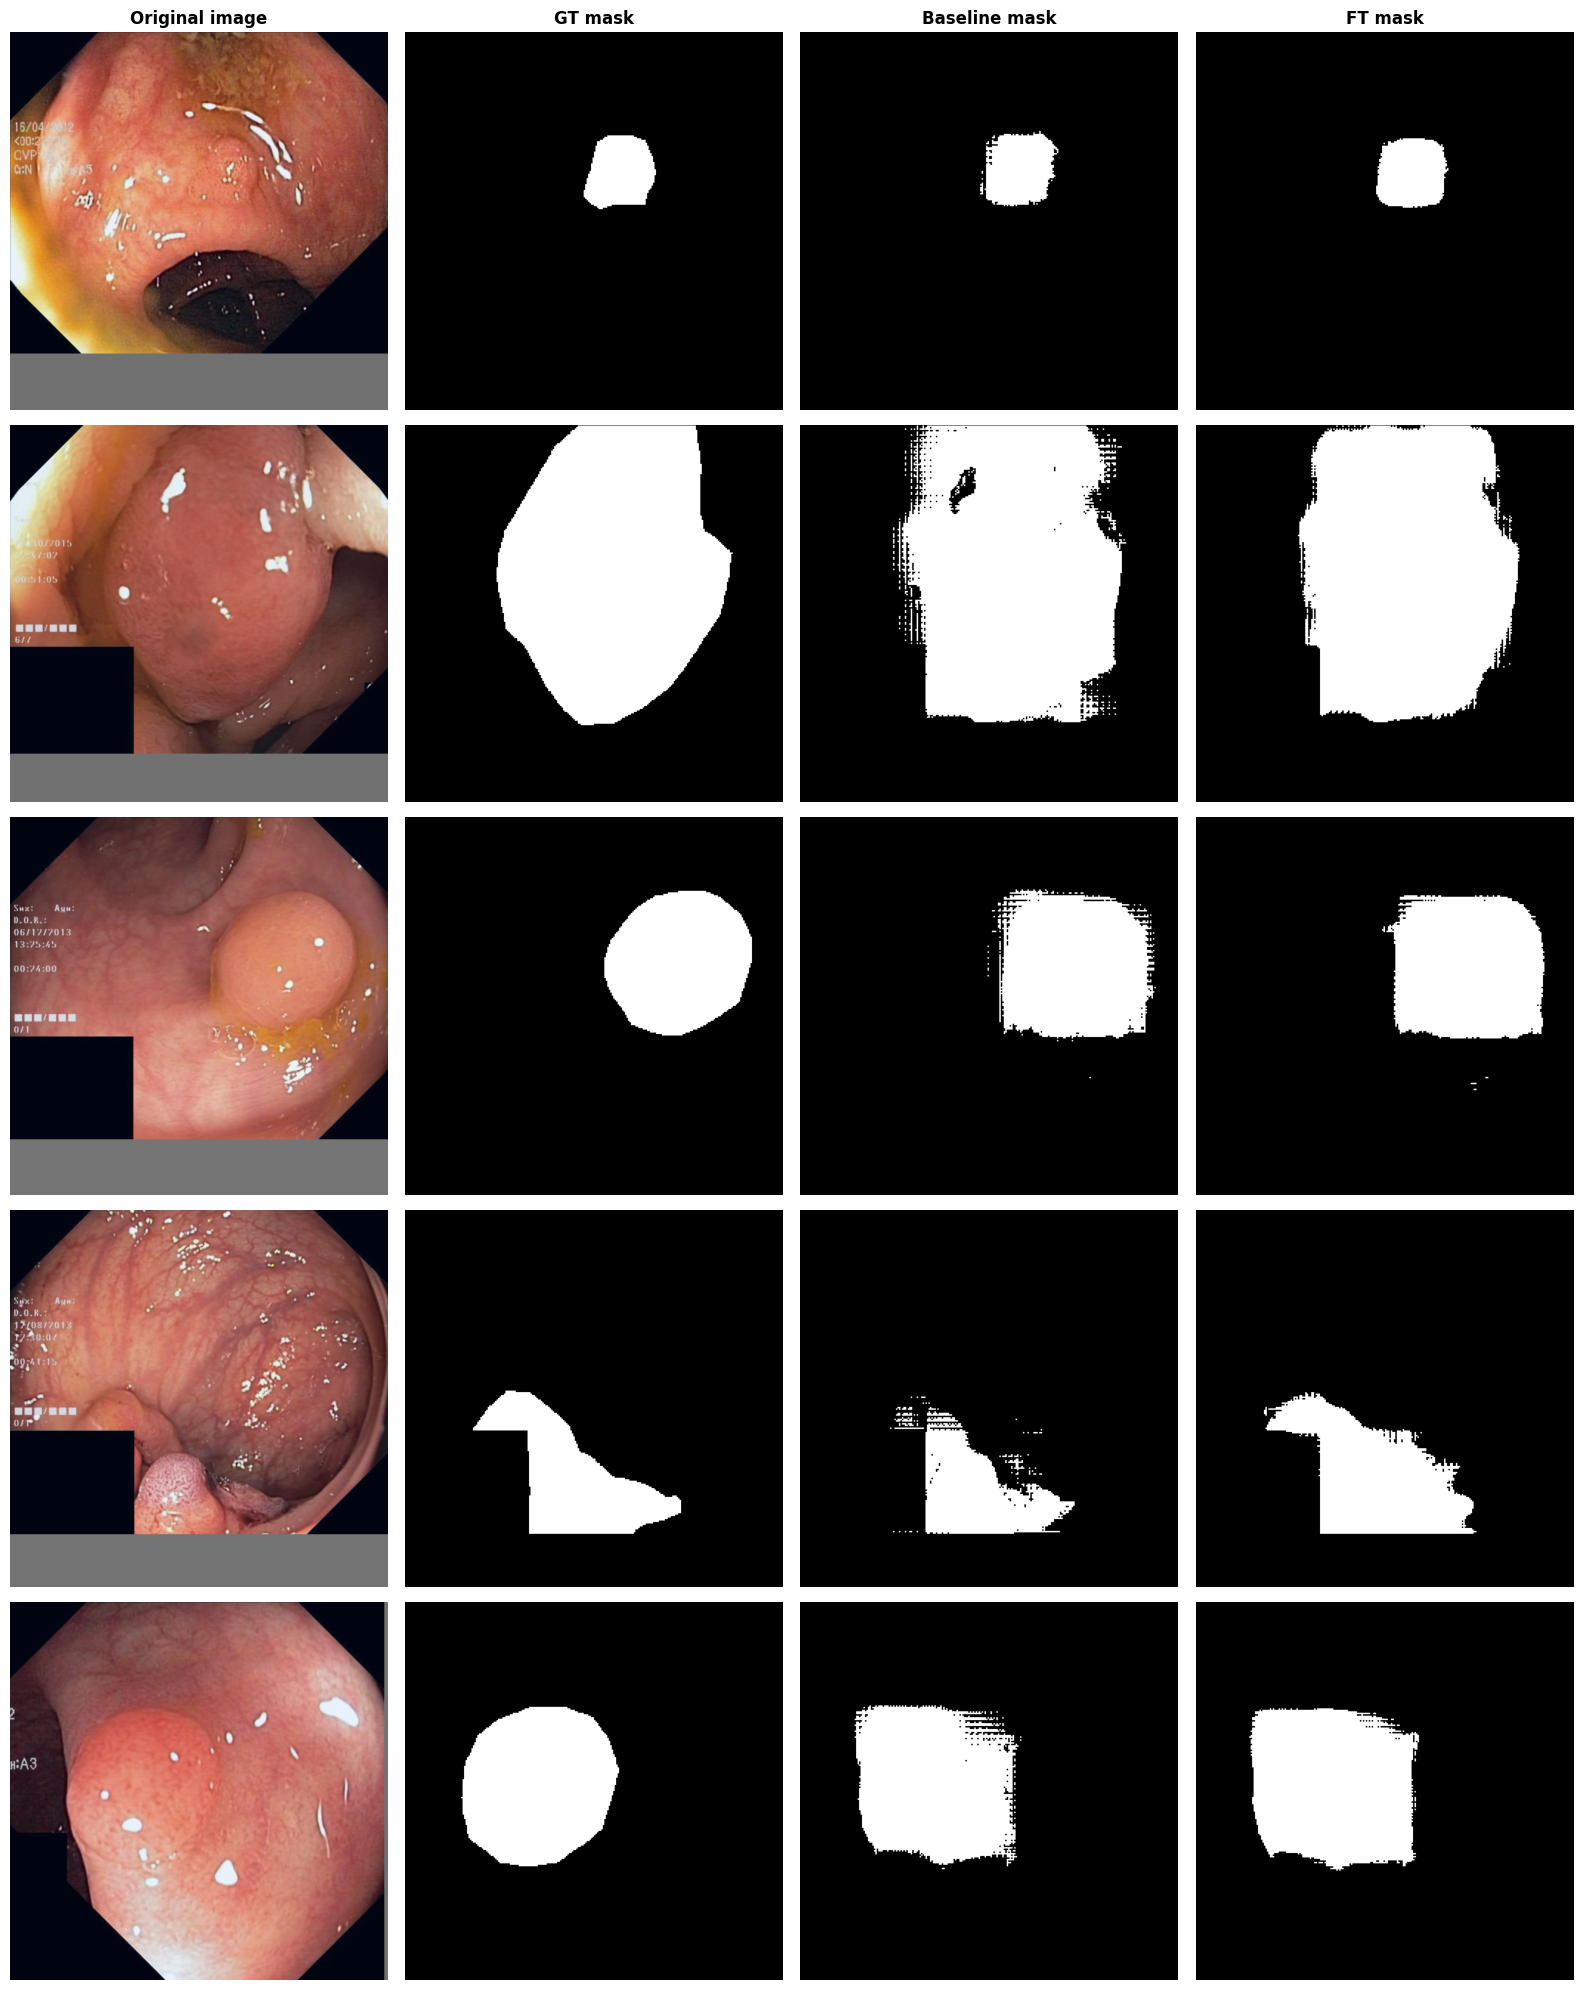

In [38]:
show_visualizations(val_dataset, model, baseline_model, device, num_examples=5)

**Interpretacja**<br>
Można dostrzec, że model dostrojony trochę lepiej rysuje maski. Te obszary, które w przypadku segmentacji zero-shot (baseline) były tylko można powiedzieć punktowo pozaznaczane, są przez FT pokryte praktycznie w całości. FT jest pewniejszy, posiada mniej "niepewnych" obszarów.

## Porównanie strategi promptowania - bounding box czy point lepszy?

Zbieramy wyniki dla modeli ft i baseline

In [39]:
print('1/4: baseline + box...')
base_box_iou, base_box_dice = evaluate_model(baseline_model,val_loader,
                                             device, prompt_type='box')
print('2/4: baseline + point...')
base_point_iou, base_point_dice = evaluate_model(baseline_model, val_loader,
                                                 device, prompt_type='point')
print('3/4: ft + box...')
ft_box_iou, ft_box_dice = evaluate_model(model, val_loader,
                                         device, prompt_type='box')
print('4/4: ft + point...')
ft_point_iou, ft_point_dice = evaluate_model(model, val_loader,
                                             device, prompt_type='point')

1/4: baseline + box...


Ewaluacja (box): 100%|██████████| 50/50 [00:10<00:00,  4.86it/s]


2/4: baseline + point...


Ewaluacja (point): 100%|██████████| 50/50 [00:10<00:00,  4.71it/s]


3/4: ft + box...


Ewaluacja (box): 100%|██████████| 50/50 [00:10<00:00,  4.86it/s]


4/4: ft + point...


Ewaluacja (point): 100%|██████████| 50/50 [00:10<00:00,  4.61it/s]


Przygotowujemy elegancką tabelę z dataframe'a pandasowego

In [40]:
data = {'Model': ['Baseline', 'Baseline', 'Fine-Tuned', 'Fine-Tuned'],
        'Prompt': ['Bounding Box', 'Punkt (Centroid)', 'Bounding Box', 'Punkt (Centroid)'],
        'Mean IoU': [base_box_iou, base_point_iou,ft_box_iou, ft_point_iou],
        'Mean Dice': [base_box_dice, base_point_dice, ft_box_dice, ft_point_dice]}
df = pd.DataFrame(data)
pivot_df = df.pivot(index='Model', columns='Prompt', values=['Mean IoU', 'Mean Dice'])
pivot_df = pivot_df.round(4)
display(pivot_df)

Mean IoU                     Mean Dice                 
Prompt     Bounding Box Punkt (Centroid) Bounding Box Punkt (Centroid)
Model                                                                 
Baseline         0.7702           0.2803       0.8599           0.3916
Fine-Tuned       0.8228           0.3561       0.8950           0.4786

## Analiza błędów - 10 najlepszych oraz 10 najgorszych

In [41]:
def get_best_and_worst_cases(model, dataset, device, prompt_type='box'):
  model.eval()
  results = [] # (img idx, iou_score)

  with torch.no_grad():
    for i in tqdm(range(len(dataset))):
      sample = dataset[i]

      batch_dummy = {'pixel_values': sample['pixel_values'].unsqueeze(0),
                     'input_boxes': sample['input_boxes'].unsqueeze(0),
                     'original_sizes': sample['original_sizes'].unsqueeze(0),
                     'labels': sample['labels'].unsqueeze(0)}
      batched_input = prepare_sam_inputs(batch_dummy, device, prompt_type)
      ground_truth_mask = batch_dummy['labels'].to(device)

      outputs = model(batched_input, multimask_output=False)
      pred_mask_256 = outputs[0]['low_res_logits'].squeeze(0).squeeze(0)

      iou, _ = calculate_metrics(pred_mask_256.unsqueeze(0), ground_truth_mask)
      results.append((i, iou))

  results.sort(key=lambda x: x[1])
  worst_10 = results[:10]
  best_10 = results[-10:]
  best_10.reverse()
  return worst_10, best_10

In [42]:
worst_10_cases, best_10_cases = get_best_and_worst_cases(model, val_dataset, device, prompt_type='box')

print('\nNajgorsze 10 (idx, IoU):', [(idx, round(iou, 4)) for idx, iou in worst_10_cases])
print('Najlepsze 10 (idx, IoU):', [(idx, round(iou, 4)) for idx, iou in best_10_cases])

100%|██████████| 200/200 [00:11<00:00, 18.05it/s]


Najgorsze 10 (idx, IoU): [(132, 0.0442), (119, 0.1522), (33, 0.2305), (128, 0.3593), (136, 0.4423), (64, 0.4654), (60, 0.4831), (78, 0.5293), (140, 0.5472), (199, 0.5948)]
Najlepsze 10 (idx, IoU): [(157, 0.9681), (65, 0.9627), (129, 0.9593), (118, 0.9585), (115, 0.9564), (51, 0.9554), (94, 0.9543), (95, 0.9537), (190, 0.9519), (26, 0.9511)]


In [43]:
def visualize_cases(model, dataset, cases_list, device, title_prefix=''):
  model.eval()
  num_cases = len(cases_list)
  fig, axes = plt.subplots(num_cases, 3, figsize=(12, 3 * num_cases))

  for row_idx, (data_idx, iou_score) in enumerate(cases_list):
    sample = dataset[data_idx]

    with torch.no_grad():
      batch_dummy = {'pixel_values': sample['pixel_values'].unsqueeze(0),
                      'input_boxes': sample['input_boxes'].unsqueeze(0),
                      'original_sizes': sample['original_sizes'].unsqueeze(0)}
      batched_input = prepare_sam_inputs(batch_dummy, device, prompt_type='box')
      outputs = model(batched_input, multimask_output=False)
      pred_mask = (outputs[0]['low_res_logits'].squeeze().cpu().numpy() > 0).astype(np.uint8)

    gt_mask = sample['labels'].numpy()
    img = sample['pixel_values'].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f'Obraz (ID: {data_idx})')
    axes[row_idx, 0].axis('off')
    axes[row_idx, 1].imshow(gt_mask, cmap='gray')
    axes[row_idx, 1].set_title('Ground Truth')
    axes[row_idx, 2].imshow(pred_mask, cmap='gray')
    axes[row_idx, 2].set_title(f'Predykcja (IoU: {iou_score:.4f})')
    axes[row_idx, 2].axis('off')

  plt.suptitle(f'{title_prefix}', fontsize=16, fontweight='bold')
  plt.tight_layout(rect=[0, 0, 1, 0.98])
  plt.show()

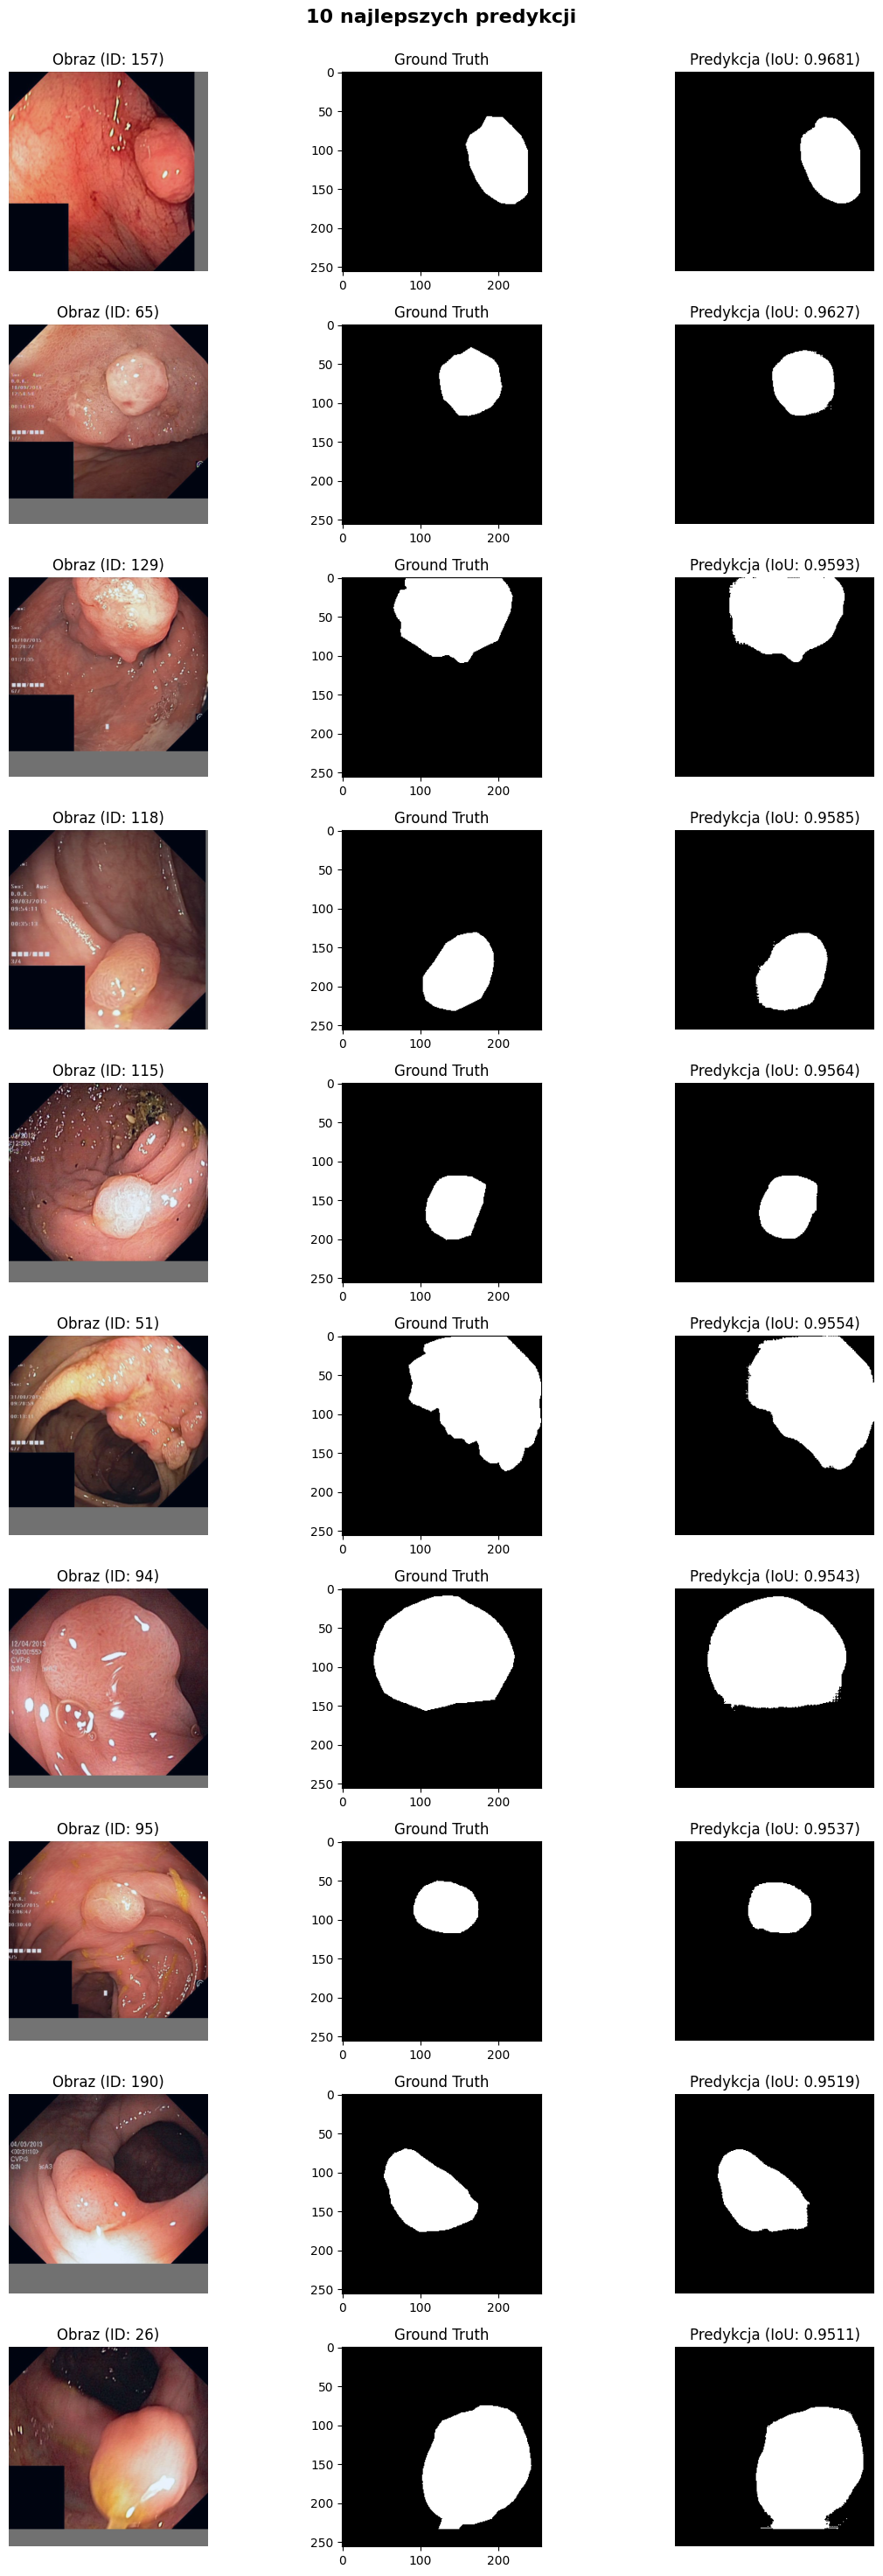

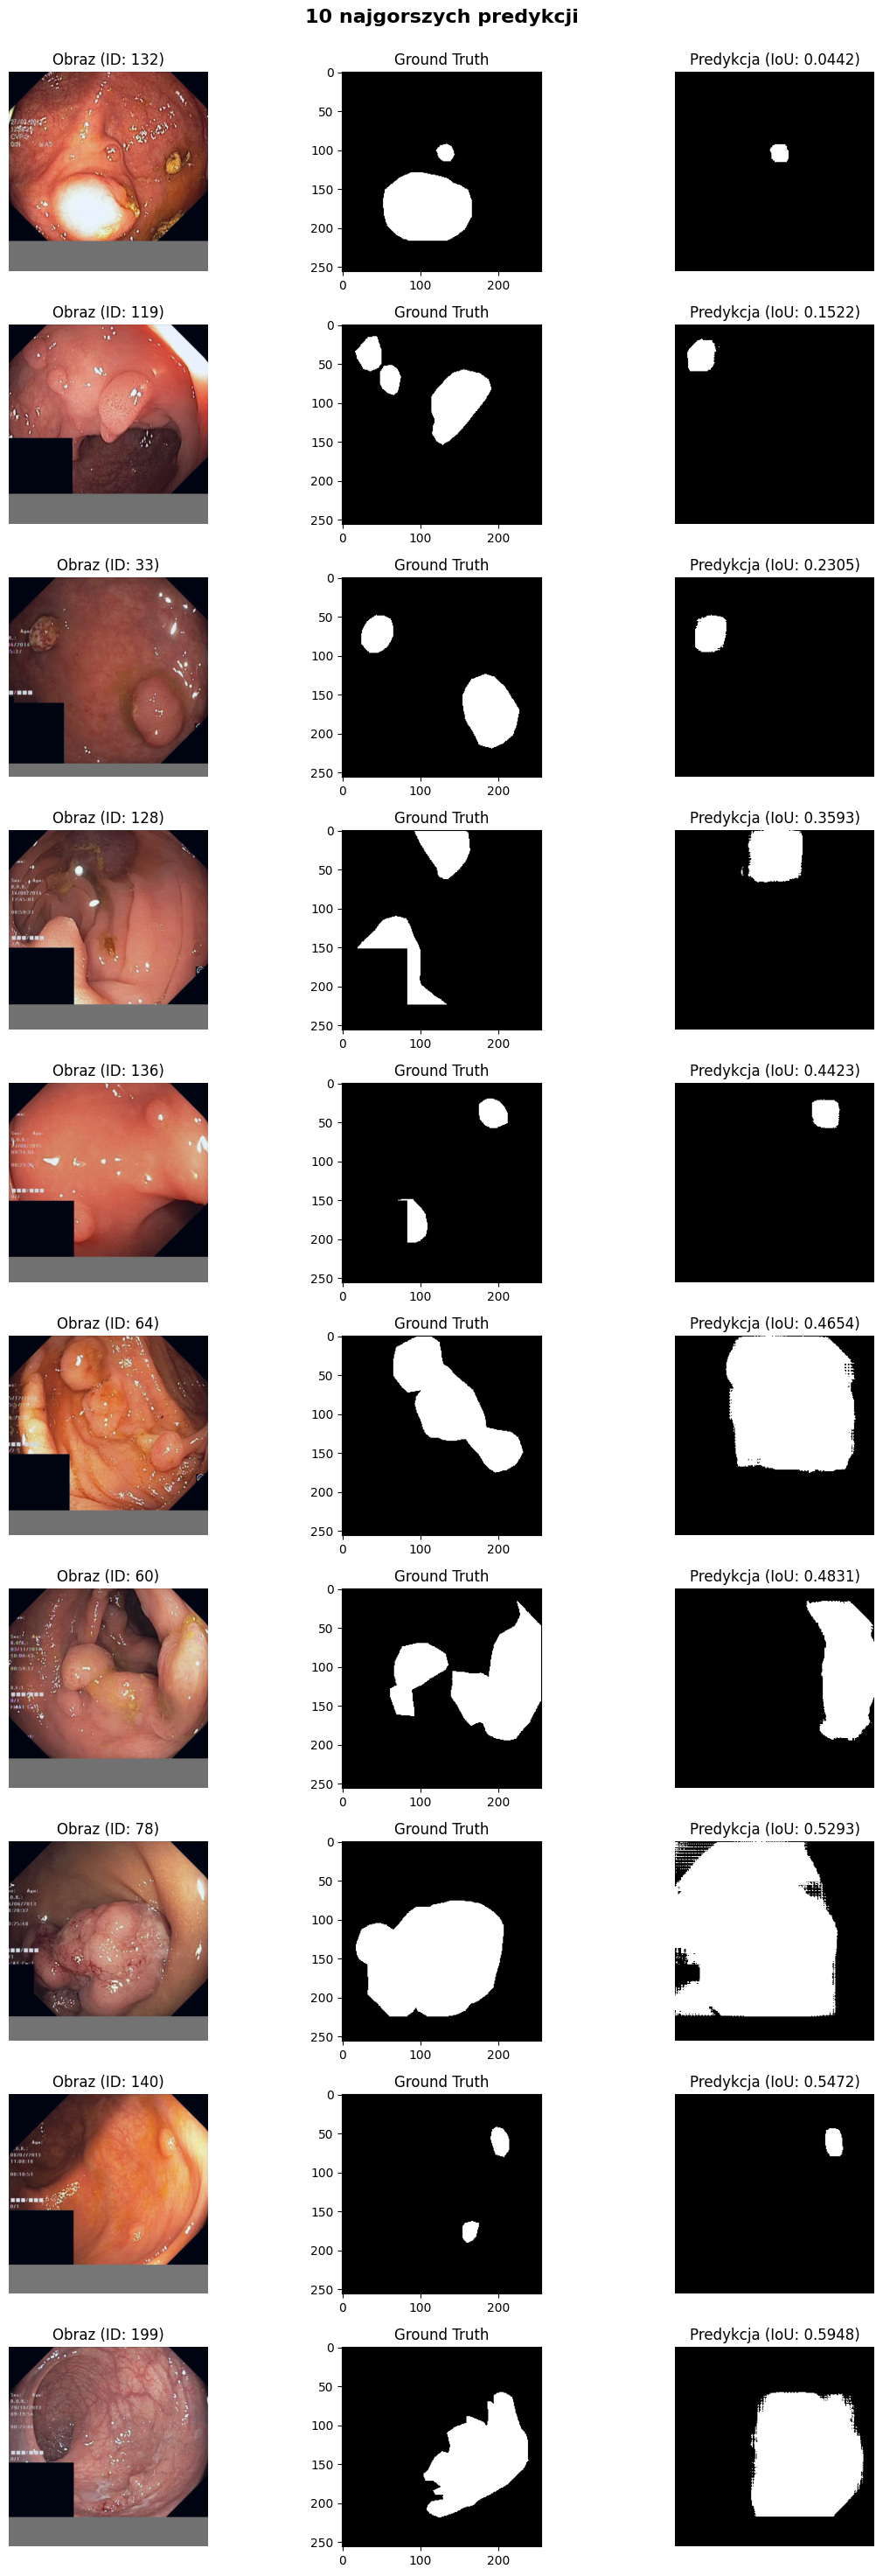

In [44]:
visualize_cases(model, val_dataset, best_10_cases, device, '10 najlepszych predykcji')
visualize_cases(model, val_dataset, worst_10_cases, device, '10 najgorszych predykcji')

**Czemu model się myli?**<br>
W przypadku 10 najgorszych predykcji można zauważyć, że częstym zjawiskiem jest egzystencja kilku polipów na jednym zdjęciu. Następnym kluczowym czynnikiem okazały się być bardzo dziwne kształty. Istotnym czynnikiem wydaje się być też umiejscowienie polipa w lewym dolnym rogu, gdzie zazwyczaj występują czarne kwadraty, które znajdują się tam w celu ukrycia pewnych wrażliwych danych medycznych. Kolory i oświetlenie też mogłyby być tutaj zaznaczone, natomiast pewnie mogłoby to mieć większe znaczenie w różnych szczególnych przypadkach, kiedy naprawdę wpływałoby to na postrzeganie obrazu, jednak widzimy, że konrast, kolory, oświetlenie też są zróżnicowane w przypadku najlepszych predykcji także nie mogą zostać w tej konkretnej sytuacji wskazane jako **pewne** przyczyny złych predykcji.

## Na co patrzy enkoder? - wizualizacja map uwagi

In [45]:
def visualize_encoder_attention(model, dataset, device, num_examples=5):
  model.eval()

  fig, axes = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))
  titles = ['Original', 'GT', 'Encoder Attention (ViT)']

  with torch.no_grad():
    for i in range(num_examples):
      sample = dataset[i]

      raw_image = sample['pixel_values'].cpu().permute(1, 2, 0).numpy()
      raw_image = (raw_image - raw_image.min()) / (raw_image.max() - raw_image.min())

      gt_mask = sample['labels'].numpy()
      images = sample['pixel_values'].to(device)
      images = model.preprocess(images).unsqueeze(0)

      # pobieramy embeddingi z enkodera
      image_embeddings = model.image_encoder(images)

      # image_embeddings ma wymiar [1, 256, 64, 64]
      # liczymy średnią po 256 kanałach, wtedy shape -> [64, 64]
      attention_map_64 = torch.mean(torch.abs(image_embeddings.squeeze(0)), dim=0)

      # min-max normalization 0...1
      attention_map_64 = attention_map_64 - attention_map_64.min()
      attention_map_64 = attention_map_64 / attention_map_64.max()

      # interpolacja do 1024x1024
      original_size = tuple(sample['original_sizes'].tolist())
      attention_map_full = F.interpolate(attention_map_64.unsqueeze(0).unsqueeze(0),
                                         size=original_size,
                                         mode='bicubic',
                                         align_corners=False).squeeze().cpu().numpy()
      # (0 niebieski)...(1 czerwony)
      axes[i, 0].imshow(raw_image)
      axes[i, 0].axis('off')
      if i == 0: axes[i, 0].set_title(titles[0], fontweight='bold', fontsize=14)
      axes[i, 1].imshow(gt_mask, cmap='gray')
      axes[i, 1].axis('off')
      if i == 0: axes[i, 1].set_title(titles[1], fontweight='bold', fontsize=14)

      # nakładanie mapy cieplnej na oryginał
      axes[i, 2].imshow(raw_image)
      axes[i, 2].imshow(attention_map_full, cmap='jet', alpha=0.5)

      axes[i, 2].axis('off')
      if i == 0: axes[i, 2].set_title(titles[2], fontweight='bold', fontsize=14)

  plt.tight_layout()
  plt.show()

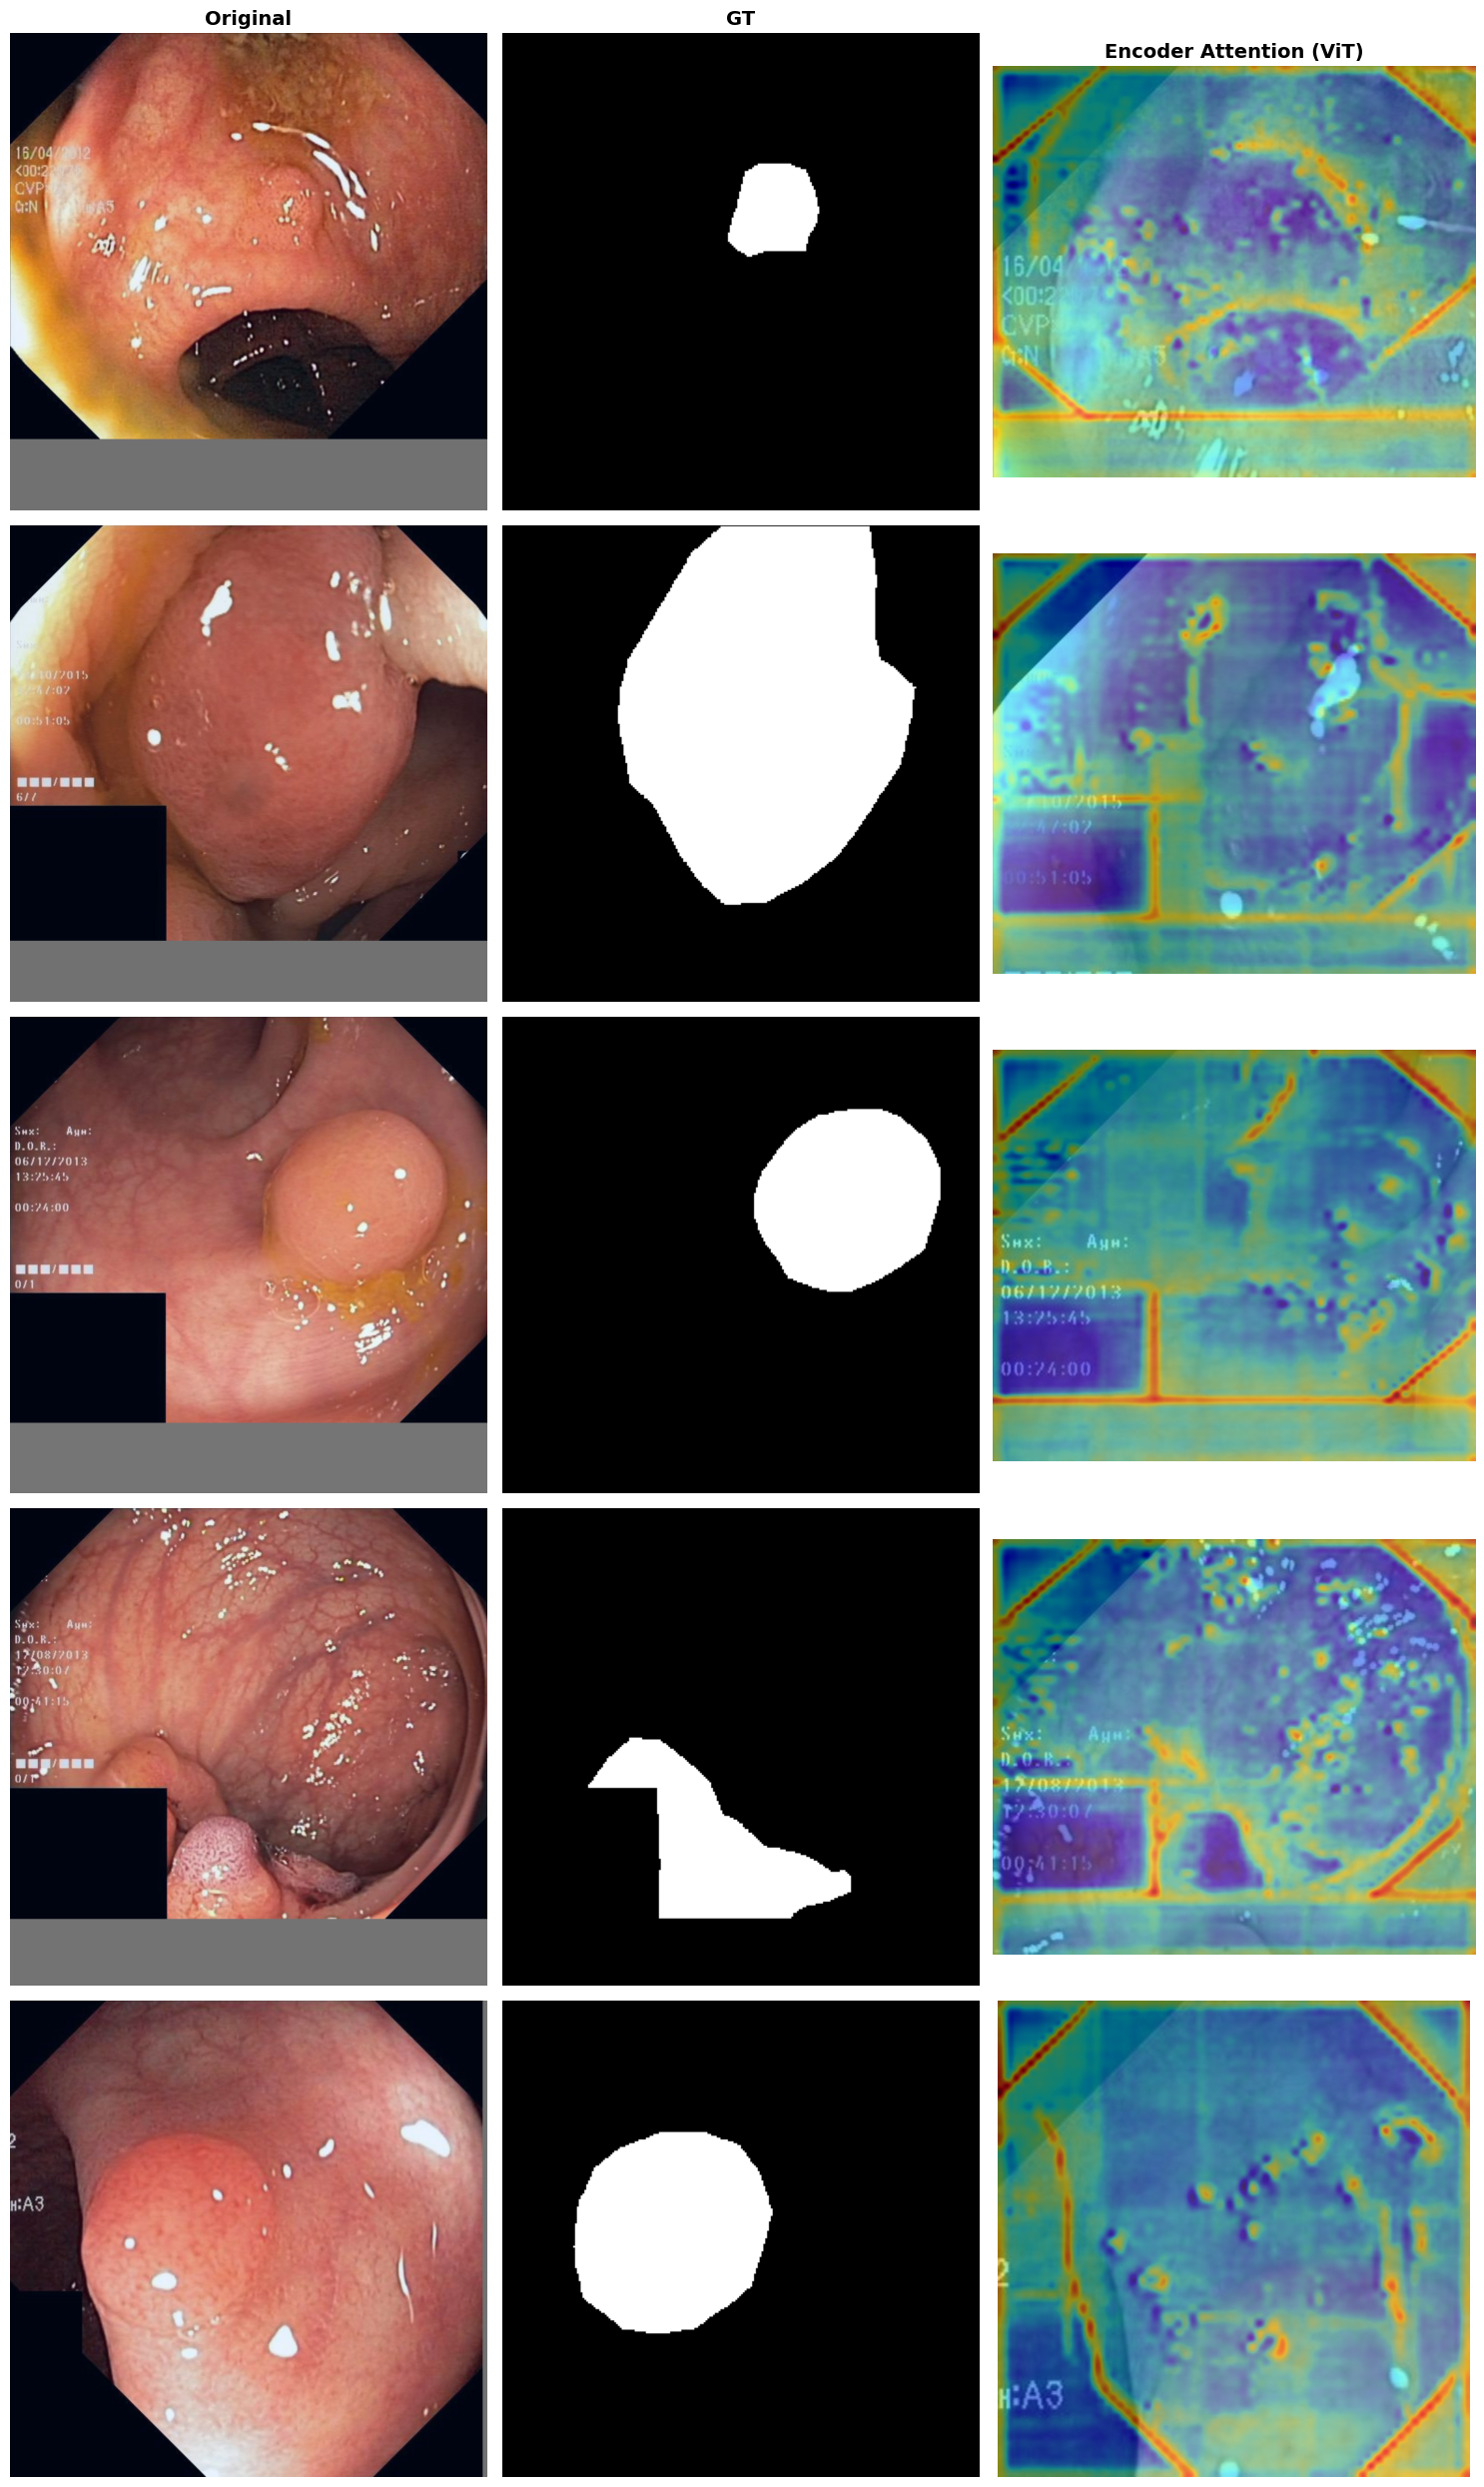

In [46]:
visualize_encoder_attention(model, val_dataset, device, num_examples=5)

**Wnioski**<br>
Obszary, na których najbardziej skupiał się enkoder (czerwony kolor) nie znajdują się na dosłownie na polipach, jednak często obtaczają je, robią pewnego rodzaju obrysowanie. Enkoder domyśla się, że w tym miejscu występuje jakiś nowy obiekt. Największa uwaga skupia się zaś w miejscach na obrazie, gdzie występuje nagła zmiana koloru, miejsce spotkania różnych obiektów.

## Interaktywna apka Gradio

In [47]:
# mózg -> dostaje obraz i go wypluwa, tylko że z maską
def run_sam_inference(image, prompt_type, points):
  # przetwarzamy oryginał na potrzeby SAMa
  original_size = image.shape[:2]
  img_tensor = torch.tensor(image).permute(2, 0, 1).float().to(device)
  batched_input = [{'image': img_tensor, 'original_size': original_size}]

  # punkt
  if prompt_type == 'Pojedynczy Punkt':
    x, y = points[0]
    batched_input[0]['point_coords'] = torch.tensor([[[x, y]]], dtype=torch.float,
                                                    device=device)
    batched_input[0]['point_labels'] = torch.tensor([[1]], dtype=torch.int,
                                                    device=device)
  # bbox
  else:
    x1, y1 = points[0]
    x2, y2 = points[1]
    xmin, xmax = min(x1, x2), max(x1, x2)
    ymin, ymax = min(y1, y2), max(y1, y2)
    batched_input[0]['boxes'] = torch.tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float, device=device)

  with torch.no_grad():
    outputs = model(batched_input, multimask_output=False)
    mask = outputs[0]['masks'].squeeze().cpu().numpy()

  # wizualizacja
  annotated_image = image.copy()
  color = np.array([255, 0, 0]) # czerwona
  # przezroczysta nakładka
  annotated_image[mask] = annotated_image[mask] * 0.5 + color * 0.5

  # rysowanie znaczników dla wizualnego feedbacku
  if prompt_type == 'Pojedynczy Punkt':
    cv2.circle(annotated_image, points[0], 6, (0, 255, 0), -1) # zielona kropka
  else:
    cv2.rectangle(annotated_image, points[0], points[1], (0, 255, 0), 3) # zielona ramka

  return annotated_image.astype(np.uint8)

# nasłuchiwanie na kliknięcia użytkownika
def process_click(original_img, current_display, prompt_type, click_coords, evt: gr.SelectData):
  if original_img is None:
    return current_display, click_coords, 'Najpierw wgraj zdjęcie.'

  # pobranie [x, y] kliknięcia z eventu Gradio
  x, y = evt.index
  click_coords.append((x, y))

  if prompt_type == 'Pojedynczy Punkt':
    res_img = run_sam_inference(original_img, prompt_type, [(x, y)])
    return res_img, click_coords, 'Wygenerowano maskę dla punktu!'
  elif prompt_type == 'Bounding Box (2 kliknięcia)':
    if len(click_coords) % 2 != 0:
      # użytkownik kliknął pierwszy róg, rysujemy punkt pomocniczy i czekamy
      img_with_pt = original_img.copy()
      cv2.circle(img_with_pt, (x, y), 6, (0, 255, 0), -1)
      return img_with_pt, click_coords, 'Zaznaczono pierwszy róg. Kliknij przeciwległy róg ramki.'
    else:
      # użytkownik kliknął drugi róg, generujemy maskę
      pts = click_coords[-2:]
      res_img = run_sam_inference(original_img, prompt_type, pts)
      return res_img, click_coords, 'Wygenerowano maskę dla Bounding Boxa!'

# reset stanu przy wgraniu nowego zdjęcia
def reset_state(img):
    return img, [], 'Wgrano nowe zdjęcie. Wybierz prompt i kliknij na obraz.'

# interfejs
with gr.Blocks(theme=gr.themes.Soft()) as demo:
  gr.Markdown('# Interaktywna Segmentacja Polipów (SAM Fine-Tuned)')
  gr.Markdown('Wgraj własne zdjęcie, wybierz strategię podpowiadania i przetestuj wytrenowany model na żywo.')

  with gr.Row():
    with gr.Column(scale=1):
      prompt_type = gr.Radio(choices=['Pojedynczy Punkt', 'Bounding Box (2 kliknięcia)'],
                             value='Pojedynczy Punkt',
                             label='Wybierz metodę promptowania:')
      status_text = gr.Textbox(label='Status operacji',
                               value='Czekam na zdjęcie...',
                               interactive=False)
      clear_btn = gr.Button('Wyczyść obraz', variant='secondary')
    with gr.Column(scale=3):
      image_component = gr.Image(label='Obszar roboczy (Kliknij tutaj)',
                                 type='numpy', interactive=True)
  # zmienne przechowujące stan w tle
  original_image_state = gr.State(None)
  click_history_state = gr.State([])

  # Akcje
  image_component.upload(reset_state,
                         inputs=[image_component],
                         outputs=[original_image_state, click_history_state, status_text])
  image_component.select(process_click, inputs=[original_image_state, image_component,
                                                 prompt_type, click_history_state],
                         outputs=[image_component, click_history_state, status_text])
  clear_btn.click(lambda img: (img, [], 'Oczyszczono. Możesz klikać ponownie.'),
                  inputs=[original_image_state],
                  outputs=[image_component, click_history_state, status_text])
# uruchamianie apki
demo.launch(inline=True, share=True)

/tmp/ipykernel_2479/702416300.py:70: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5816621252b9a4ec8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
